# Intro til Machine Learning — 1: Autograd og gradient descent

I regressionsemnet fandt I den bedste rette linje gennem en punktsky **med en formel**.
Det var smart — men formlen findes kun, fordi lineær regression er et simpelt problem.
For neurale netværk findes der *ingen formel*. I stedet skal computeren **lede sig frem**
til de bedste tal, lidt ad gangen. Den metode hedder **gradient descent**, og den er
motoren i stort set al moderne AI.

I denne notebook møder I:
1. **Autograd** — PyTorch' indbyggede, automatiske differentiering (afsnit 2)
2. **Gradient descent** — og lineær regression én gang til, nu på den nye måde (afsnit 3)

> **Om opgaverne:** Der er med vilje flere opgaver, end I kan nå — ingen forventes at nå alt. Opgaver mærket **(ekstra)** er til jer, der er foran; opgaver mærket **(find fejlen)** har en bevidst fejl, som I skal finde og rette (så en fejl dér er meningen).

**Emnets køreplan:** 1) Autograd & gradient descent *(I er her)* → 2) Neurale netværk → 3) Aktiveringsfunktioner → 4) MNIST & Pokémon.

## Setup

In [1]:
# Henter Pokémon-data fra GitHub (Plan B: upload Pokemon.csv manuelt via mappeikonet i Colab)
!wget -q -nc https://raw.githubusercontent.com/UNF-Science-Camps/KIC26/main/Intro-ML/data/Pokemon.csv

In [2]:
# Henter vores lille plottehjælper fra GitHub (kun matplotlib-pynt, ingen magi)
!wget -q -nc https://raw.githubusercontent.com/UNF-Science-Camps/KIC26/main/Intro-ML/hjaelpefunktioner.py

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from hjaelpefunktioner import plot_gd_skridt

torch.manual_seed(42)
np.random.seed(42)

> **Plan B:** Fejler `wget`-cellen, så hent `hjaelpefunktioner.py` fra GitHub-repoet
> (mappen `Intro-ML`) og upload den manuelt via Colabs filpanel (mappeikonet til venstre).

Og så skal vi selvfølgelig have Pokémonerne med igen:

In [4]:
df = pd.read_csv("Pokemon.csv")
df.head(3)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


# 1: Autograd — den automatiske hældningsmåler

Nu til tensorernes superkraft nummer ét. I kender **differentialkvotienten** fra gymnasiet:
$f'(x)$ måler, hvor stejl grafen for $f$ er i punktet $x$ — og hvilken vej den hælder.

PyTorch kan regne den ud **automatisk**, uanset hvor indviklet funktionen er. Det virker
sådan her:

1. Opret en tensor med `requires_grad=True` — "hold øje med denne variabel!"
2. Regn noget ud med den — PyTorch husker i smug alle mellemregninger.
3. Kald `.backward()` på resultatet — PyTorch regner baglæns og finder gradienten.
4. Aflæs gradienten i `.grad`.

Lad os tjekke, at PyTorch kan differentiere $f(x) = x^2$ (vi ved jo, at $f'(x) = 2x$):

In [5]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print("PyTorch siger: f'(3) =", x.grad)
print("Og i hånden:   f'(3) = 2 · 3 =", 2 * 3)

PyTorch siger: f'(3) = tensor(6.)
Og i hånden:   f'(3) = 2 · 3 = 6


PyTorch fandt $f'(3) = 6$ — uden at kende formlen $f'(x) = 2x$ ! Den har simpelthen
regnet baglæns gennem udregningen. Ordet **gradient** er bare ML-sprog for
differentialkvotient (og den generaliserer til funktioner af mange variable).

Lad os *se* hvad gradienten betyder — den er hældningen af tangenten i punktet:

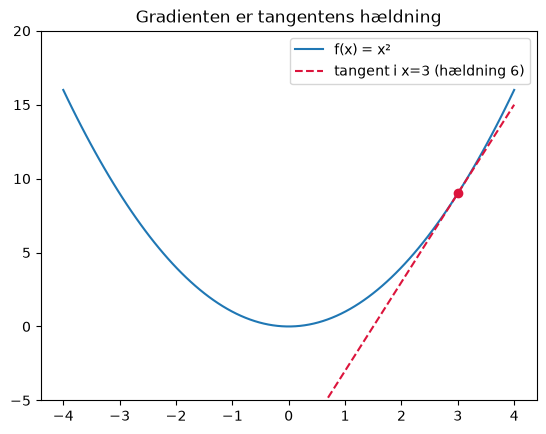

In [6]:
xs = np.linspace(-4, 4, 100)
plt.plot(xs, xs ** 2, label="f(x) = x²")

# tangenten i x = 3 har hældningen f'(3) = 6:
haeldning = x.grad.item()
plt.plot(xs, haeldning * (xs - 3) + 9, "--", color="crimson",
         label=f"tangent i x=3 (hældning {haeldning:.0f})")
plt.scatter([3], [9], color="crimson", zorder=3)
plt.ylim(-5, 20)
plt.legend()
plt.title("Gradienten er tangentens hældning")
plt.show()

## Hvorfor er det smart?

Gradientens **fortegn** fortæller, hvilken vej grafen går *op* ad bakke. Positiv gradient i
et punkt? Så bliver $f$ større, hvis $x$ vokser. I machine learning har vi en **tabsfunktion**
(husk MSE fra regressionsemnet — den måler, hvor *forkert* modellen er), og vi vil gøre tabet
så **lille** som muligt. Så vi skal altid gå **imod** gradienten — *ned* ad bakken.

Det er hele hemmeligheden bag næste afsnit. Men først: prøv selv autograd.

### Opgaver

##### Opgave 2.1
Koden finder gradienten af $f(x) = x^2$ i $x = 3$. Ændr den, så den i stedet finder
gradienten af $f(x) = x^3 + 2x$ i $x = 2$. Regn først facit i hånden
($f'(x) = 3x^2 + 2$) — og tjek så, om PyTorch er enig.

In [7]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print(x.grad)

tensor(6.)


##### Opgave 2.2
Udfyld de to manglende linjer, så gradienten af $f(x) = 5x^2 - x$ i $x = 1$ bliver beregnet
og printet.

In [8]:
x = torch.tensor(1.0, requires_grad=True)
y = 5 * x ** 2 - x
y....()
print(x....)

SyntaxError: invalid syntax (39512261.py, line 3)

##### Opgave 2.3 (find fejlen)
Nogen ville finde en gradient, men `x.grad` er `None`, og `.backward()` brokker sig oven
i købet. Der mangler noget helt afgørende ved oprettelsen af tensoren — find det og ret det.

In [ ]:
x = torch.tensor(4.0)
y = x ** 2
y.backward()
print(x.grad)

##### Opgave 2.4
Kør cellen nedenfor. Gradienten af $x^2$ i $x=3$ er 6... men der bliver printet **12**!
Kig på loopet: `.backward()` bliver kaldt to gange, uden at `.grad` bliver nulstillet
imellem. Hvad gør PyTorch åbenbart med gradienter, når man kalder `.backward()` flere gange?

In [ ]:
x = torch.tensor(3.0, requires_grad=True)
for i in range(2):
    y = x ** 2
    y.backward()
print(x.grad)   # 12?! Ikke 6?

##### Opgave 2.5 (ekstra)
Autograd virker også med **flere variable**. Find gradienten af $f(a, b) = a^2 + 3b$ i
punktet $(a, b) = (2, 5)$ — udfyld hullerne. I hånden: $\frac{\partial f}{\partial a} = 2a$
og $\frac{\partial f}{\partial b} = 3$. Hvad fortæller de to tal hver især?

In [ ]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(5.0, requires_grad=True)
f = ...
f.backward()
print("gradient for a:", a.grad)
print("gradient for b:", b.grad)

##### Opgave 2.6
Hvis gradienten i et punkt er **negativ** — skal vi så gøre $x$ større eller mindre for at
komme *ned* ad bakken? Og hvad hvis den er positiv? Formulér en generel regel med jeres
egne ord.

*Skriv jeres svar her:* $\dots$

##### Opgave 2.7
Udfyld linjen, der regner baglæns, så gradienten af $f(x)=x^3$ i $x=2$ bliver fundet (facit: 12).

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3
...            # ← regn baglæns
print("gradient:", x.grad.item())   # f'(x) = 3x², så 3·2² = 12

##### Opgave 2.8
Gradienten er jo ikke ét tal — den afhænger af, HVOR man står. Kør cellen, og skift så
tallene i listen ud, så du ser $f'(x)=2x$ for flere punkter.

In [ ]:
for punkt in [-2.0, 0.0, 1.0, 3.0]:   # ← prøv dine egne
    x = torch.tensor(punkt, requires_grad=True)
    y = x ** 2
    y.backward()
    print(f"gradient i x={punkt}: {x.grad.item()}")

##### Opgave 2.9 (ekstra)
Brug gradienten til at tage ÉT gradient descent-skridt væk fra tabet. Udfyld skridtet
(det er lige det, næste afsnit handler om).

In [ ]:
x = torch.tensor(4.0, requires_grad=True)
y = (x - 1) ** 2                  # minimum ligger i x = 1
y.backward()
laeringsrate = 0.1
with torch.no_grad():
    nyt_x = x - laeringsrate * ...    # ← gang læringsraten med gradienten
print(f"fra x=4 (tab {y.item():.1f}) til x={nyt_x.item():.2f} — tættere på 1")

# 2: Gradient descent — at rulle ned ad bakken

Nu samler vi det hele. Opskriften på **gradient descent** er tre linjer:

1. Stå et sted (start med en tilfældig værdi af $a$).
2. Mærk hældningen (regn gradienten).
3. Tag et lille skridt **ned** ad bakken: $a_{\text{ny}} = a - \text{læringsrate} \cdot \text{gradient}$.

...og gentag med en for-løkke, indtil man står i bunden. **Læringsraten** bestemmer, hvor
store skridt man tager — det bliver vigtigt om lidt.

Vi starter med en funktion, hvor vi kan se facit med det blotte øje: $f(a) = (a-3)^2$ har
selvfølgelig sit minimum i $a = 3$. Differentialkvotienten kan I selv regne: $f'(a) = 2(a-3)$.

In [ ]:
def f(a):
    return (a - 3) ** 2

def f_maerke(a):              # f'(a) = 2(a - 3), regnet i hånden
    return 2 * (a - 3)

laeringsrate = 0.1
a = -2.0                      # startgæt — langt fra minimum
skridt = [a]

for i in range(20):
    a = a - laeringsrate * f_maerke(a)    # ← SELVE gradient descent-linjen
    skridt.append(a)

print("Efter 20 skridt står vi i a =", round(a, 4))
plot_gd_skridt(f, skridt, titel="Gradient descent på f(a) = (a-3)²")

Sådan! Fra startgættet $a = -2$ ruller vi ned og lander (næsten) i $a = 3$. Bemærk at
skridtene bliver mindre og mindre af sig selv — tæt på bunden er gradienten lille, så
$\text{læringsrate} \cdot \text{gradient}$ bliver også lille. Elegant, ikke?

## Læringsraten: for lille, tilpas, for stor

Læringsraten er gradient descents vigtigste indstilling. Se, hvad der sker med en
tilpas (0.1) og en alt for stor (1.05) læringsrate:

In [ ]:
fig, akser = plt.subplots(1, 2, figsize=(12, 4))

for akse, lr in zip(akser, [0.1, 1.05]):
    a = -2.0
    skridt = [a]
    for i in range(15):
        a = a - lr * f_maerke(a)
        skridt.append(a)
    xs = np.linspace(min(skridt) - 1, max(skridt) + 1, 200)
    akse.plot(xs, f(xs), color="steelblue")
    akse.plot(skridt, [f(s) for s in skridt], "o-", color="crimson", alpha=0.7)
    akse.set_title(f"læringsrate = {lr} → ender i a = {a:.1f}")
plt.show()

Med læringsrate 1.05 tager vi så store skridt, at vi **hopper forbi** bunden og lander
højere oppe på den anden side — igen og igen. Tabet *vokser* for hvert skridt.

## Lineær regression — nu uden formel

Tilbage til det, I kender: find den bedste linje $y = ax + b$ gennem en punktsky. I
regressionsemnet brugte I en formel. Nu lader vi gradient descent finde $a$ og $b$ — og
denne gang må autograd regne gradienterne (ingen håndkraft!).

Vi prøver at forudsige en Pokémons `Total` ud fra dens `Attack`. Begge kolonner
standardiseres først (notebook 1-tricket!), så tallene er pæne:

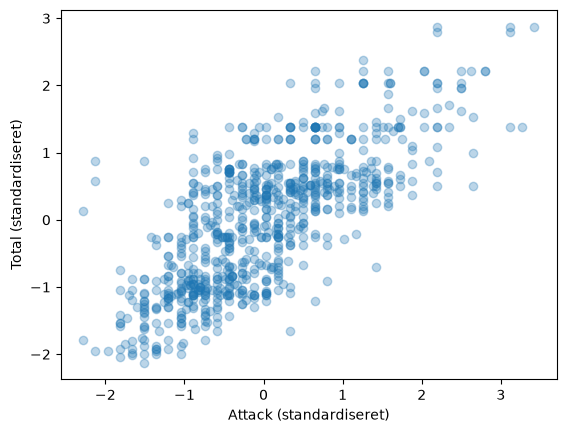

In [9]:
x = torch.tensor(df["Attack"].values, dtype=torch.float32)
y = torch.tensor(df["Total"].values, dtype=torch.float32)

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

plt.scatter(x, y, alpha=0.3)
plt.xlabel("Attack (standardiseret)")
plt.ylabel("Total (standardiseret)")
plt.show()

In [10]:
a = torch.tensor(0.0, requires_grad=True)   # start: en flad linje
b = torch.tensor(0.0, requires_grad=True)
laeringsrate = 0.1
tab_historik = []

for epoke in range(100):
    y_hat = a * x + b                      # 1. modellens gæt for ALLE 800 Pokémon
    tab = ((y_hat - y) ** 2).mean()        # 2. MSE: hvor forkerte er vi i snit?
    tab.backward()                         # 3. autograd finder gradienterne
    with torch.no_grad():                  # 4. tag ét skridt ned ad bakken
        a -= laeringsrate * a.grad
        b -= laeringsrate * b.grad
    a.grad.zero_()                         # 5. nulstil gradienter (husk opgave 2.4!)
    b.grad.zero_()
    tab_historik.append(tab.item())

print(f"Linjen blev: y = {a.item():.3f}·x + {b.item():.3f}")

Linjen blev: y = 0.736·x + -0.000


(Detalje: `with torch.no_grad():` betyder "dette er ikke en del af modellen, kig væk,
autograd" — selve opdaterings-skridtet skal jo ikke differentieres. Og `.zero_()` nulstiller
gradienterne, så de ikke hober sig op, jf. opgave 2.4.)

Én gennemløbning af alle data kaldes en **epoke** — deraf løkkevariablen. Lad os se
resultatet og **tabskurven** — ML-folkets vigtigste diagnoseværktøj. Den skal falde og
flade ud:

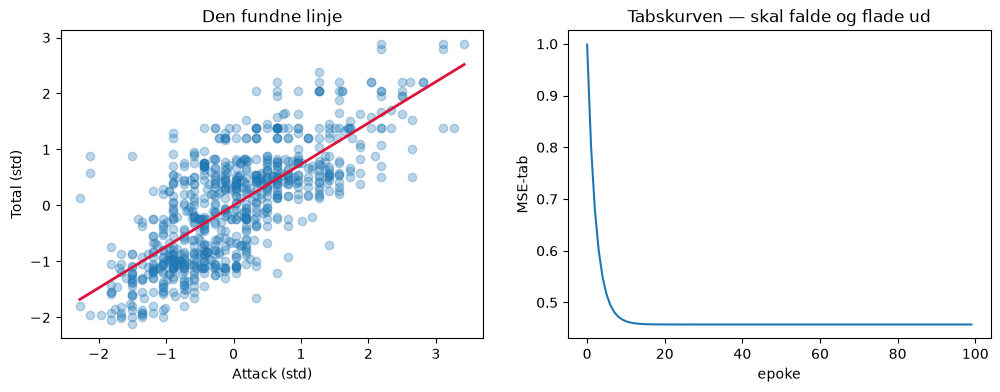

In [11]:
fig, akser = plt.subplots(1, 2, figsize=(12, 4))

akser[0].scatter(x, y, alpha=0.3)
xs = torch.linspace(x.min(), x.max(), 100)
with torch.no_grad():
    akser[0].plot(xs, a * xs + b, color="crimson", linewidth=2)
akser[0].set_title("Den fundne linje")
akser[0].set_xlabel("Attack (std)")
akser[0].set_ylabel("Total (std)")

akser[1].plot(tab_historik)
akser[1].set_title("Tabskurven — skal falde og flade ud")
akser[1].set_xlabel("epoke")
akser[1].set_ylabel("MSE-tab")
plt.show()

## Flere features på én gang

Hvorfor nøjes med `Attack`? Med matrix-multiplikation kan linjen få **seks** hældninger —
én pr. stat: $\hat{y} = X\,\vec{w} + b$. Og her har Pokémon-datasættet en indbygget
facitliste: `Total` er jo bogstaveligt talt **summen** af de seks stats! Så den perfekte
model har alle seks vægte = 1 og bias = 0.

Denne gang standardiserer vi ikke, men deler alt med 100 (samme skalering for alle
kolonner, så facit stadig passer — og tallene stadig er pæne):

In [13]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
X = torch.tensor(df[stats].values, dtype=torch.float32) / 100
y = torch.tensor(df["Total"].values, dtype=torch.float32) / 100

w = torch.zeros(6, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
learning_rate = 0.1

for epoch in range(3000):
    y_hat = X @ w + b
    tab = ((y_hat - y) ** 2).mean()
    tab.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    w.grad.zero_()
    b.grad.zero_()

print("vægte:", w.detach().numpy().round(3), "— facit: 1, 1, 1, 1, 1, 1")
print("bias:  ", round(b.item(), 4), "— facit: 0")
print("sluttab:", round(tab.item(), 6))

vægte: [1. 1. 1. 1. 1. 1.] — facit: 1, 1, 1, 1, 1, 1
bias:   0.0 — facit: 0
sluttab: 0.0


Gradient descent **opdagede selv**, at Total er summen af de seks stats — vi har på
intet tidspunkt fortalt den det! Det er machine learning i en nøddeskal: mønstret lå i
dataene, og optimeringen fandt det.

## De indbyggede klodser: tabsfunktion og optimizer

Vores håndskrevne loop virker, men PyTorch har færdige klodser til delene: `nn.MSELoss()`
er vores MSE-linje, og `torch.optim.SGD` holder styr på opdatering + nulstilling. Samme
loop, nu med klodserne — læg mærke til **tre-trins-rytmen** i loopet, for den skal I kunne
i søvne: **`zero_grad()` → `backward()` → `step()`**

In [14]:
import torch.nn as nn

model = nn.Linear(6, 1)                                  # 6 features ind → 1 tal ud (w OG b indbygget!)
tabsfunktion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoke in range(3000):
    optimizer.zero_grad()                    # 1. nulstil gamle gradienter
    y_hat = model(X).squeeze()               # (forward: modellens gæt)
    tab = tabsfunktion(y_hat, y)             # (regn tabet)
    tab.backward()                           # 2. find gradienterne
    optimizer.step()                         # 3. tag ét skridt ned ad bakken

print("vægte:", model.weight.detach().numpy().round(3))
print("bias: ", round(model.bias.item(), 4))

vægte: [[1. 1. 1. 1. 1. 1.]]
bias:  0.0


Samme resultat — bare med mindre bogholderi. (`.squeeze()` fjerner en overflødig
dimension: `model(X)` giver shape (800, 1), men `y` har shape (800).)

`nn.Linear(6, 1)` er i øvrigt jeres allerførste **netværkslag** — i notebook 3 stabler vi
sådan nogle oven på hinanden, og så har I et neuralt netværk. Men først: opgaver!

### Opgaver

##### Opgave 3.1
Kør gradient descent på $f(a) = (a-3)^2$ med læringsraterne **0.01, 0.1, 0.9 og 1.05**
(én ad gangen). Beskriv med jeres egne ord, hvad der sker i hvert af de fire tilfælde.

In [15]:
laeringsrate = 0.01   # ← prøv 0.01, 0.1, 0.9 og 1.05
a = -2.0
skridt = [a]
for i in range(20):
    a = a - laeringsrate * f_maerke(a)
    skridt.append(a)
print("ender i a =", round(a, 3))
plot_gd_skridt(f, skridt, titel=f"læringsrate = {laeringsrate}")

NameError: name 'f_maerke' is not defined

##### Opgave 3.2
Med læringsrate 0.1: prøv forskellige startpunkter (`a = -2.0`, `a = 100.0`, `a = 3.0`) og
forskellige antal skridt. Cirka hvor mange skridt kræver det at komme tættere på minimum
end 0.001, når man starter i $a = 100$? (Ret i tallene og aflæs!)

In [ ]:
laeringsrate = 0.1
a = 100.0
antal_skridt = 20   # ← skru op og ned
for i in range(antal_skridt):
    a = a - laeringsrate * f_maerke(a)
print("afstand til minimum:", abs(a - 3))

##### Opgave 3.3
Udfyld selve gradient descent-linjen (opdateringen af `a`) i skabelonen — resten står klar.

In [ ]:
laeringsrate = 0.1
a = -2.0
for i in range(30):
    a = ...   # ← ét skridt NED ad bakken (brug f_maerke(a))
print("ender i a =", round(a, 4))

##### Opgave 3.4 (find fejlen)
Loopet nedenfor skulle finde minimum... men `a` stikker af i den helt forkerte retning og
bliver bare større og større! Find fortegnsfejlen og ret den.

In [ ]:
laeringsrate = 0.1
a = -2.0
skridt = [a]
for i in range(15):
    a = a + laeringsrate * f_maerke(a)
    skridt.append(a)
print("ender i a =", round(a, 1), "— det skulle have været 3!")

##### Opgave 3.5 (find fejlen)
Dette autograd-loop burde opføre sig præcis som det håndregnede — men skridtene bliver
vildere og vildere, og `a` eksploderer. Én vigtig linje er faldet ud af loopet. Hvilken?
(Tænk tilbage på opgave 2.4...)

In [ ]:
laeringsrate = 0.1
a = torch.tensor(-2.0, requires_grad=True)
for i in range(15):
    tab = (a - 3) ** 2
    tab.backward()
    with torch.no_grad():
        a -= laeringsrate * a.grad
print("ender i a =", a.item(), "— av.")

##### Opgave 3.6 (ekstra)
Funktionen $f(x) = x^4 - 3x^2 + x$ har **to dale**. Kør gradient descent med start i
$x = 2$ og bagefter i $x = -2$ (læringsrate 0.01, 80 skridt). I lander to forskellige
steder! Hvad betyder det for gradient descent som metode — finder den altid *det bedste*
minimum?

In [ ]:
def g(x):
    return x ** 4 - 3 * x ** 2 + x

start = 2.0   # ← prøv også -2.0
x = torch.tensor(start, requires_grad=True)
skridt = [x.item()]
for i in range(80):
    tab = g(x)
    tab.backward()
    with torch.no_grad():
        x -= 0.01 * x.grad
    x.grad.zero_()
    skridt.append(x.item())
print("ender i x =", round(x.item(), 3))
plot_gd_skridt(g, skridt, titel=f"start = {start}")

##### Opgave 3.7
Udfyld MSE-linjen i regressionsloopet (kvadrér fejlen og tag gennemsnittet — se formlen i
kommentaren).

In [ ]:
x = torch.tensor(df["Attack"].values, dtype=torch.float32)
y = torch.tensor(df["Total"].values, dtype=torch.float32)
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

a = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
for epoke in range(100):
    y_hat = a * x + b
    tab = ...             # MSE: gennemsnittet af (y_hat - y)²
    tab.backward()
    with torch.no_grad():
        a -= 0.1 * a.grad
        b -= 0.1 * b.grad
    a.grad.zero_()
    b.grad.zero_()
print("tab:", round(tab.item(), 4), "| linje: y =", round(a.item(), 3), "· x +", round(b.item(), 3))

##### Opgave 3.8
1D-regressionen forudsagde `Total` ud fra `Attack`. Skift x-variablen til `Defense`, `HP`
og `Speed` (én ad gangen — genbrug cellen fra opgave 3.7) og notér sluttabet for hver.
Hvilken enkelt stat er den bedste "Total-spåkugle"?

In [ ]:
x = torch.tensor(df["Attack"].values, dtype=torch.float32)   # ← skift kolonnen her
x = (x - x.mean()) / x.std()
# ...og kør så 7.7-loopet igen

##### Opgave 3.9 (ekstra)
Kør multi-feature-regressionen **uden** at dele med 100 — altså på de rå tal (fjern
`/ 100` begge steder). Hvad sker der med tabet? Prøv at redde situationen ved at gøre
læringsraten meget mindre (fx 0.00001). Hvad lærer det os om skalering af data?

In [ ]:
X_raa = torch.tensor(df[stats].values, dtype=torch.float32)   # ingen / 100 !
y_raa = torch.tensor(df["Total"].values, dtype=torch.float32)

w = torch.zeros(6, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
laeringsrate = 0.1

for epoke in range(50):
    y_hat = X_raa @ w + b
    tab = ((y_hat - y_raa) ** 2).mean()
    tab.backward()
    with torch.no_grad():
        w -= laeringsrate * w.grad
        b -= laeringsrate * b.grad
    w.grad.zero_()
    b.grad.zero_()
print("tab efter 50 epoker:", tab.item())

##### Opgave 3.10
Udfyld tre-trins-rytmen (`zero_grad` → `backward` → `step`) i den indbyggede version.

In [ ]:
X = torch.tensor(df[stats].values, dtype=torch.float32) / 100   # samme data som før
y = torch.tensor(df["Total"].values, dtype=torch.float32) / 100

model = nn.Linear(6, 1)
with torch.no_grad():
    model.weight.zero_()   # start i nul ligesom den manuelle version, så turen er den samme
    model.bias.zero_()
tabsfunktion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoke in range(3000):
    optimizer....()
    y_hat = model(X).squeeze()
    tab = tabsfunktion(y_hat, y)
    tab....()
    optimizer....()

print("vægte:", model.weight.detach().numpy().round(3))

##### Opgave 3.11
I regressionsemnet fandt I den bedste linje med en formel — på ét sekund, uden løkker.
Hvorfor gider vi så overhovedet bøvle med gradient descent? Og hvad var det egentlig,
gradient descent "opdagede" i multi-feature-eksemplet, som vi aldrig fortalte den?

*Skriv jeres svar her:* $\dots$

# Godt gået!

I har nu hele motoren: tensorer, autograd og gradient descent — og I har set PyTorch finde
mønstre i data helt selv.

**Næste stop:** `3-Neurale-netvaerk.ipynb`, hvor `nn.Linear`-klodserne stables til et rigtigt
neuralt netværk (med jeres klasse-viden fra intro-programmering i hovedrollen), og hvor I
træner det til at spotte legendariske Pokémon.